# Import Library

In [1]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 925.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 67.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [2]:
import math
import random
import pickle
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub
import time
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    label_ranking_average_precision_score,
    label_ranking_loss,
    coverage_error)
from sklearn.utils import shuffle
from scipy.signal import resample
from sklearn.preprocessing import OneHotEncoder
from keras.models import Model
from keras.layers import (
    Bidirectional,
    LSTM,
    Input,
    Dense,
    Conv1D,
    MaxPooling1D,
    Softmax,
    Add,
    Flatten,
    Activation)
from keras import backend as K
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


# Exploratory Data Analysis - EDA

## Membaca Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print("Path to dataset files:", path)

df1 = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
df2 = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)
df = pd.concat([df1, df2])

Using Colab cache for faster access to the 'heartbeat' dataset.
Path to dataset files: /kaggle/input/heartbeat


In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Visualisasi Sinyal

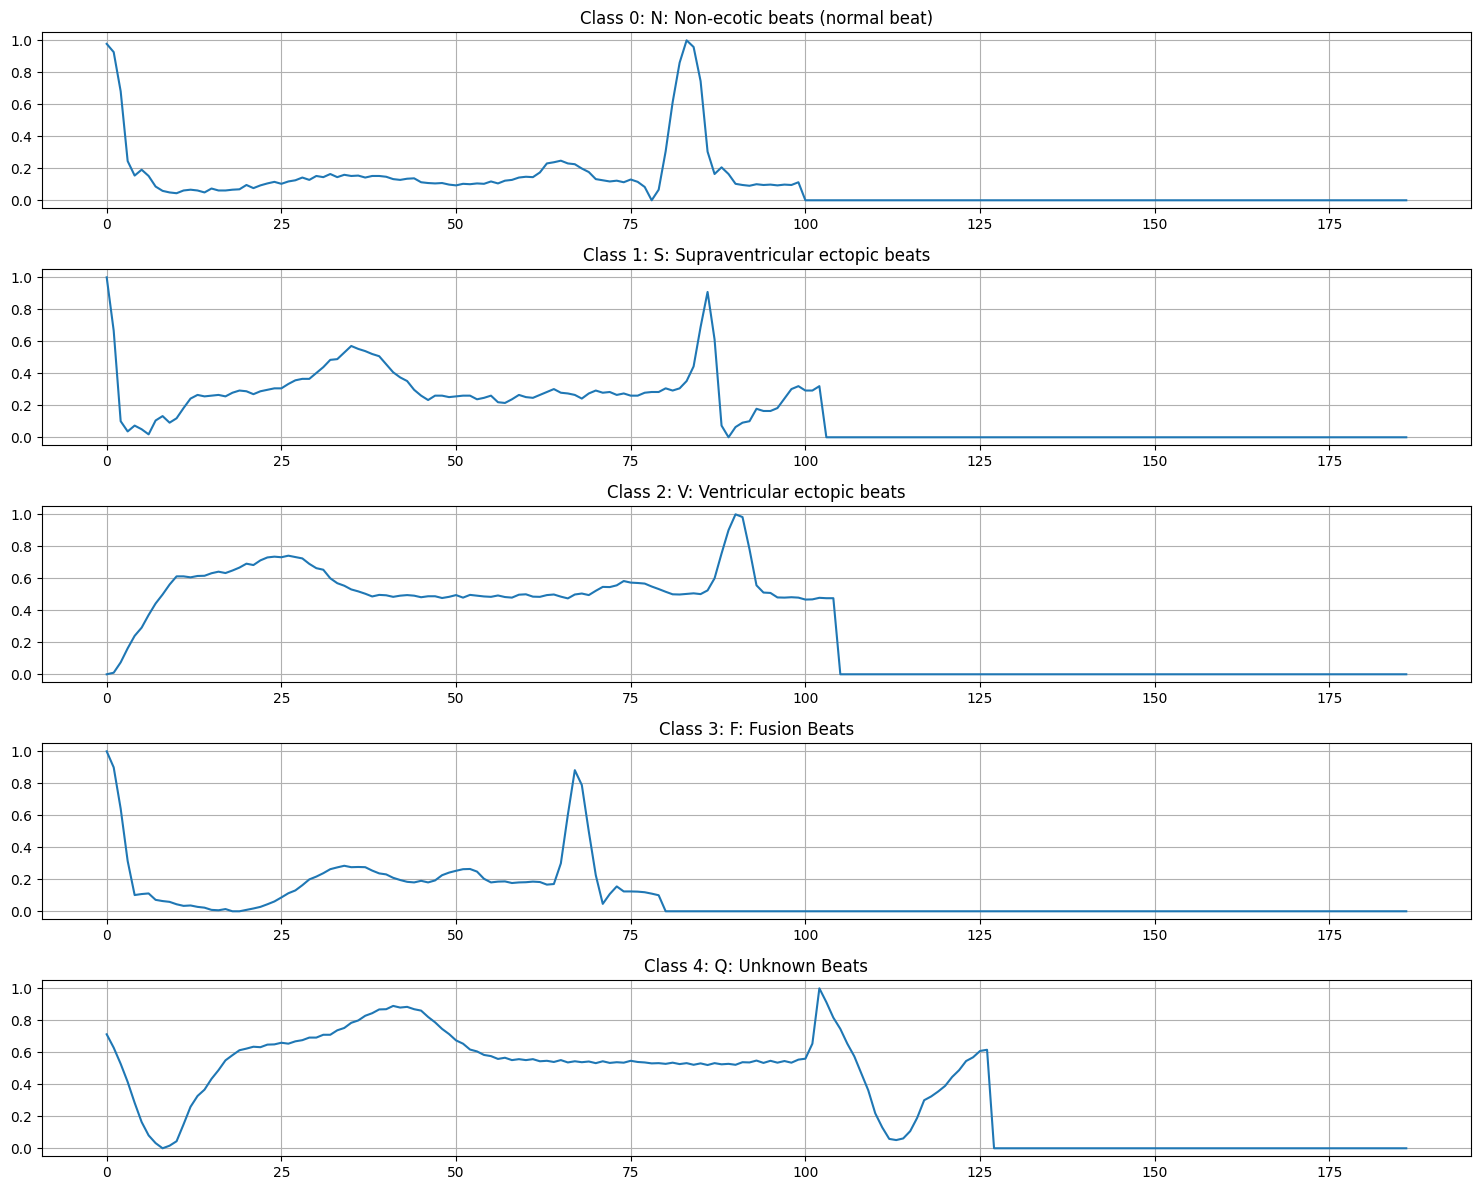

In [5]:
classes = [0, 1, 2, 3, 4]
labels = [
    'N: Non-ecotic beats (normal beat)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(15, 12))

for i, cls in enumerate(classes):
    # Ambil sampel pertama untuk setiap kelas
    sample = df[df[187] == cls].iloc[0, :187]

    plt.subplot(5, 1, i + 1)
    plt.plot(sample)
    plt.title(f"Class {cls}: {labels[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Analisis Distribusi Kelas

Jumlah sampel per kelas:
187
0.0    90589
1.0     2779
2.0     7236
3.0      803
4.0     8039
Name: count, dtype: int64


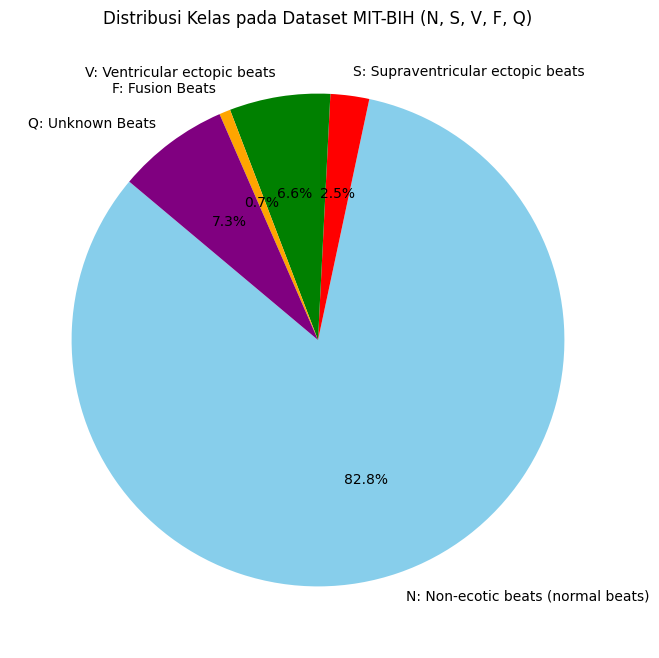

In [6]:
count_classes = df[187].value_counts().sort_index()
print("Jumlah sampel per kelas:")
print(count_classes)

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(10, 8))
plt.pie(count_classes, labels=labels_detailed, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'red', 'green', 'orange', 'purple'])
plt.title("Distribusi Kelas pada Dataset MIT-BIH (N, S, V, F, Q)")
plt.show()

# Data Preprocessing

## Pemisahan Fitur dan Target

In [7]:
X = df.iloc[:, :187].values
y = df.iloc[:, 187].values

print("Ukuran Fitur (X):", X.shape)
print("Ukuran Target (y):", y.shape)

Ukuran Fitur (X): (109446, 187)
Ukuran Target (y): (109446,)


## Penanganan Data Tidak Seimbang

In [8]:
def resample_dataset(df):
    # Pisahkan setiap kelas
    df_0 = df[df[187] == 0]
    df_1 = df[df[187] == 1]
    df_2 = df[df[187] == 2]
    df_3 = df[df[187] == 3]
    df_4 = df[df[187] == 4]

    # Target jumlah sampel per kelas
    target_samples = 20000

    # Resampling untuk setiap kelas
    df_0_resampled = df_0.sample(n=target_samples, random_state=42) # Undersampling
    df_1_resampled = df_1.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_2_resampled = df_2.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_3_resampled = df_3.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_4_resampled = df_4.sample(n=target_samples, replace=True, random_state=42) # Oversampling

    # Gabungkan kembali
    df_resampled = pd.concat([df_0_resampled, df_1_resampled, df_2_resampled, df_3_resampled, df_4_resampled])
    return df_resampled

# Terapkan resampling
df_balanced = resample_dataset(df)

# Update X dan y dengan data yang sudah seimbang
X_balanced = df_balanced.iloc[:, :187].values
y_balanced = df_balanced.iloc[:, 187].values

print("Distribusi kelas setelah resampling:")
print(df_balanced[187].value_counts().sort_index())
print("\nUkuran X_balanced:", X_balanced.shape)

Distribusi kelas setelah resampling:
187
0.0    20000
1.0    20000
2.0    20000
3.0    20000
4.0    20000
Name: count, dtype: int64

Ukuran X_balanced: (100000, 187)


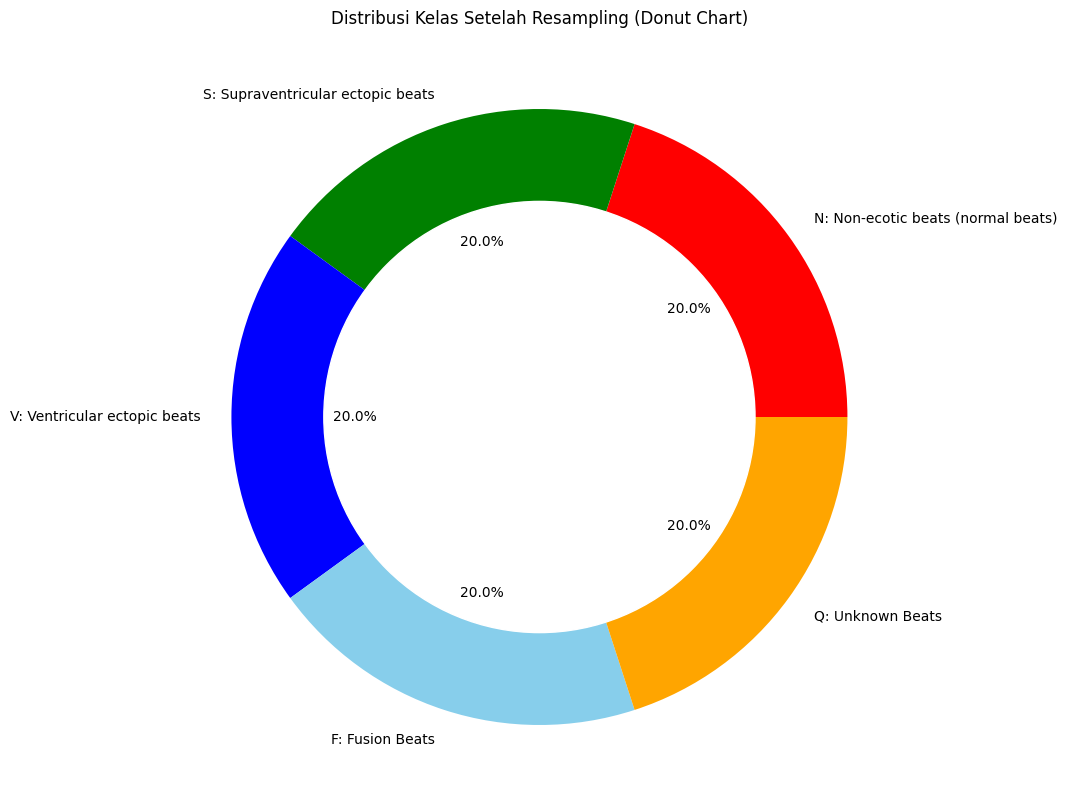

In [9]:
equilibre = df_balanced[187].value_counts()

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(20,10))
my_circle = plt.Circle((0,0), 0.7, color='white')
plt.pie(equilibre, labels=labels_detailed, colors=['red','green','blue','skyblue','orange'], autopct='%1.1f%%')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Distribusi Kelas Setelah Resampling (Donut Chart)")
plt.show()

## Reshaping Data

In [10]:
# Reshaping data fitur dari 2D (100000, 187) menjadi 3D (100000, 187, 1)
X_3d = X_balanced.reshape(X_balanced.shape[0], X_balanced.shape[1], 1)

print("Ukuran X_balanced awal:", X_balanced.shape)
print("Ukuran X setelah Reshape (X_3d):", X_3d.shape)

Ukuran X_balanced awal: (100000, 187)
Ukuran X setelah Reshape (X_3d): (100000, 187, 1)


# Pembangunan Model (Modeling)

In [11]:
from keras.layers import Dropout, Conv1D, GlobalAveragePooling1D

# 1. One-hot Encoding untuk Target
ohe = OneHotEncoder()
y_balanced_ohe = ohe.fit_transform(y_balanced.reshape(-1, 1)).toarray()

# 2. Definisi Arsitektur Model Temporal Convolutional Network (TCN) Sederhana
def build_tcn_model(input_shape):
    inp = Input(shape=input_shape)

    # Residual Block / TCN Block 1
    x = Conv1D(filters=64, kernel_size=3, dilation_rate=1, padding='causal', activation='relu')(inp)
    x = Conv1D(filters=64, kernel_size=3, dilation_rate=2, padding='causal', activation='relu')(x)

    # TCN Block 2
    x = Conv1D(filters=128, kernel_size=3, dilation_rate=4, padding='causal', activation='relu')(x)
    x = Conv1D(filters=128, kernel_size=3, dilation_rate=8, padding='causal', activation='relu')(x)

    # Global Pooling instead of Flatten for temporal data
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.2)(x)

    # Simple Classifier
    x = Dense(32, activation='relu')(x)
    out = Dense(5, activation='softmax')(x)

    tcn_model = Model(inputs=inp, outputs=out)
    return tcn_model

# Inisialisasi Model
# Karena kode berikutnya menggunakan variabel 'bi_lstm_model', kita tetap gunakan nama tersebut atau sesuaikan
tcn_model = build_tcn_model(input_shape=(187, 1))
tcn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 187, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 187, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 187, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 187, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,885 (355.02 KB)

 Trainable params: 90,885 (355.02 KB)

 Non-trainable params: 0 (0.00 B)

## Split Data

In [12]:
# Tahap 1: Split 70% Training dan 30% Sisa (Val + Test)
X_train, X_rem, y_train, y_rem = train_test_split(
    X_3d, y_balanced_ohe, test_size=0.3, random_state=42, stratify=y_balanced_ohe
)

# Tahap 2: Split Sisa (30%) menjadi 50% Val dan 50% Test (sehingga masing-masing 15% dari total)
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem
)

print(f"X_train shape: {X_train.shape} (70%)")
print(f"X_val shape:   {X_val.shape} (15%)")
print(f"X_test shape:  {X_test.shape} (15%)")

X_train shape: (70000, 187, 1) (70%)
X_val shape:   (15000, 187, 1) (15%)
X_test shape:  (15000, 187, 1) (15%)


# Training Model (1)

In [ ]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate1 = 0.01
epochs = 20
batch_size = 32

tcn_model.compile(
    optimizer=Adam(learning_rate=learning_rate1),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history1 = tcn_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6026 - loss: 0.9444
Epoch 1: val_accuracy improved from None to 0.87533, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 230s 104ms/step - accuracy: 0.7464 - loss: 0.6481 - val_accuracy: 0.8753 - val_loss: 0.3380
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8662 - loss: 0.3601
Epoch 2: val_accuracy improved from 0.87533 to 0.89627, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 223s 102ms/step - accuracy: 0.8746 - loss: 0.3387 - val_accuracy: 0.8963 - val_loss: 0.2573
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8925 - loss: 0.2920
Epoch 3: val_accuracy improved from 0.89627 to 0.92887, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 222s 102ms/step - accuracy: 0.8971 -

# Evaluasi Metrik (1)

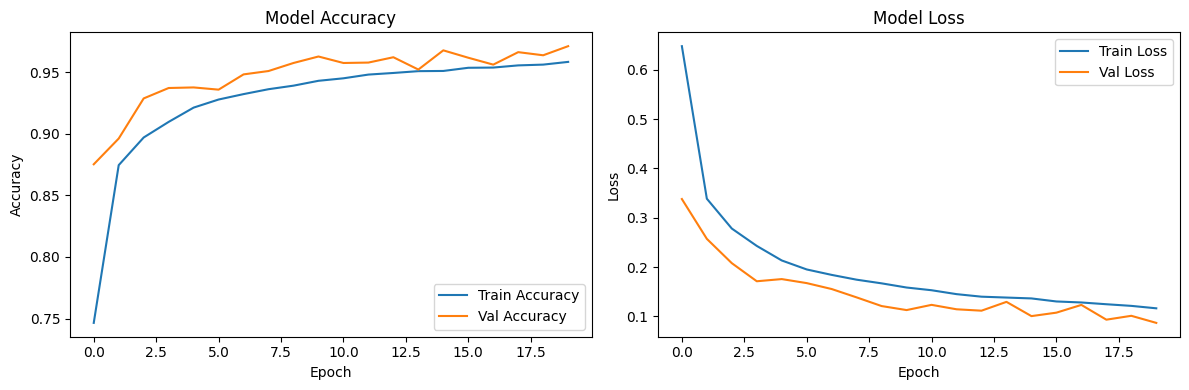

In [ ]:
# Visualisasi Hasil Pelatihan
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = tcn_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time1 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss1, accuracy1 = tcn_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate1}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss1:.4f}")
print(f"Test Accuracy: {accuracy1:.4f}")
print(f"Total Prediction Time: {total_time1:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step
Learning Rate: 0.01
Epochs: 20
Batch size: 32
Test Loss: 0.0780
Test Accuracy: 0.9729
Total Prediction Time: 31.24 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.944     0.955     0.949      3000
Supraventricular      0.963     0.959     0.961      3000
     Ventricular      0.985     0.972     0.979      3000
          Fusion      0.976     0.988     0.982      3000
         Unknown      0.998     0.990     0.994      3000

        accuracy                          0.973     15000
       macro avg      0.973     0.973     0.973     15000
    weighted avg      0.973     0.973     0.973     15000



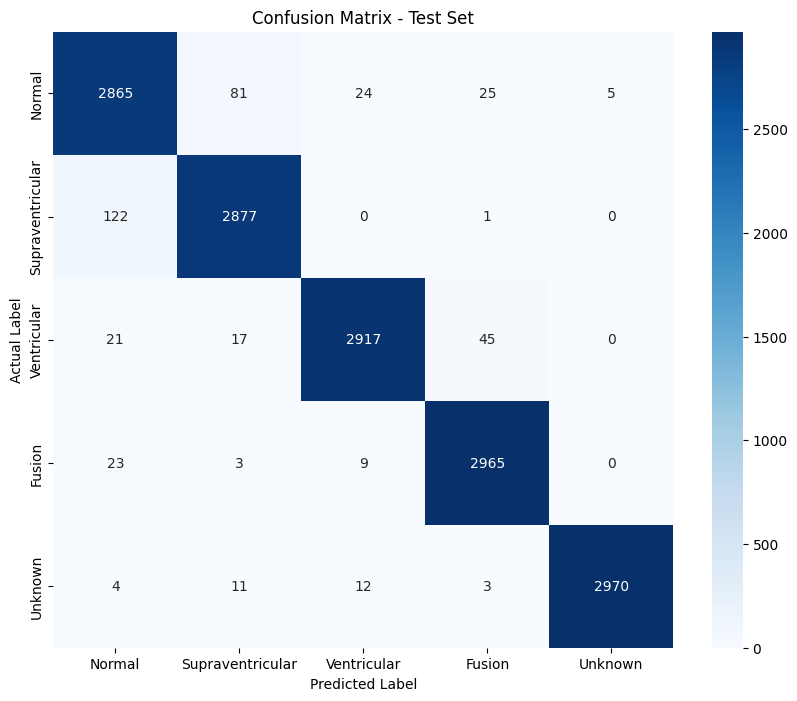

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

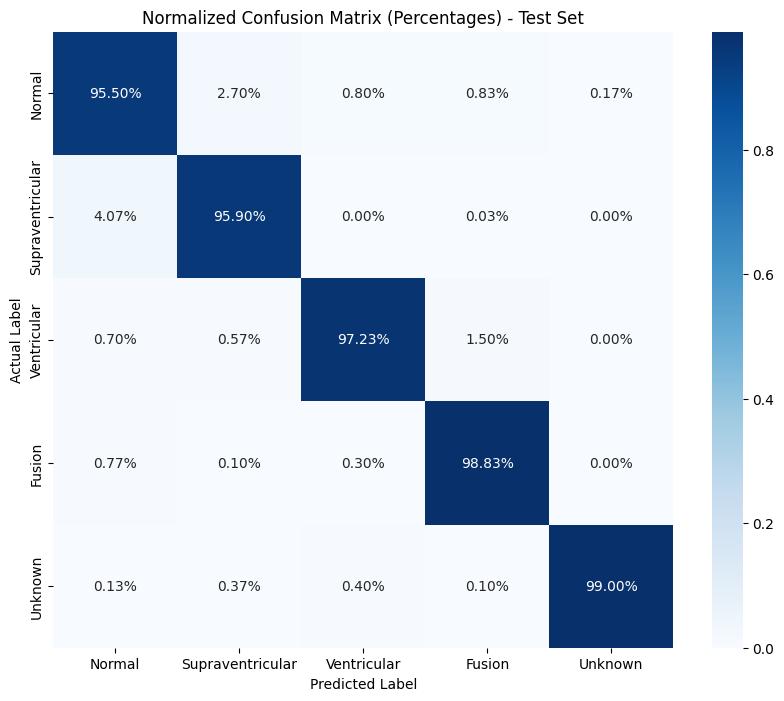

In [ ]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (2)

In [ ]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate2 = 0.005
epochs = 20
batch_size = 32

tcn_model.compile(
    optimizer=Adam(learning_rate=learning_rate2),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history2 = tcn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9688 - loss: 0.0879
Epoch 1: val_accuracy improved from None to 0.97760, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 230s 104ms/step - accuracy: 0.9697 - loss: 0.0853 - val_accuracy: 0.9776 - val_loss: 0.0723
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9713 - loss: 0.0812
Epoch 2: val_accuracy improved from 0.97760 to 0.98107, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 266s 106ms/step - accuracy: 0.9716 - loss: 0.0815 - val_accuracy: 0.9811 - val_loss: 0.0629
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9737 - loss: 0.0748
Epoch 3: val_accuracy did not improve from 0.98107
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 228s 104ms/step - accuracy: 0.9740 - loss: 0.0754 - val_accuracy: 0.9701 - val_loss: 0.0869
Epoch 4/20
2188/2188 ━━━━━━━━━━━━━

# Evaluasi Metrik (2)

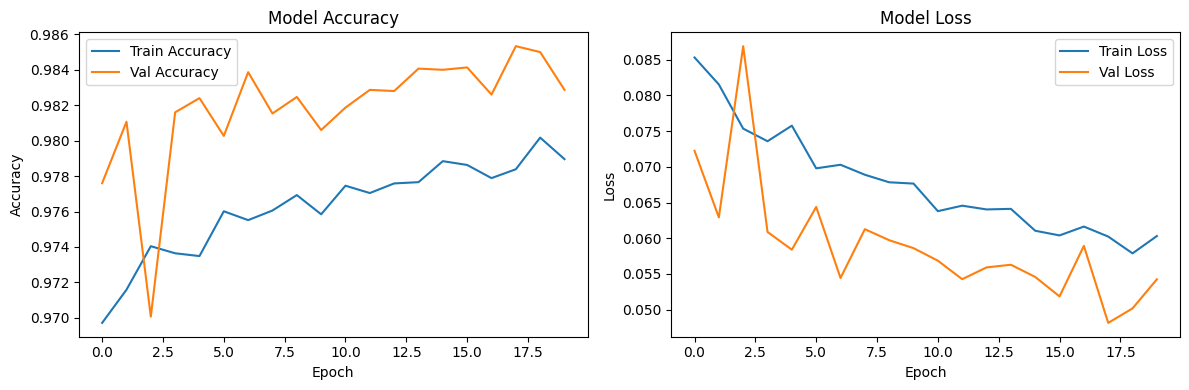

In [ ]:
# Visualisasi Hasil Pelatihan
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = tcn_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time2 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss2, accuracy2 = tcn_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate2}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss2:.4f}")
print(f"Test Accuracy: {accuracy2:.4f}")
print(f"Total Prediction Time: {total_time2:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step
Learning Rate: 0.005
Epochs: 20
Batch size: 32
Test Loss: 0.0466
Test Accuracy: 0.9851
Total Prediction Time: 41.50 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.984     0.953     0.968      3000
Supraventricular      0.968     0.987     0.977      3000
     Ventricular      0.991     0.988     0.990      3000
          Fusion      0.987     1.000     0.993      3000
         Unknown      0.996     0.998     0.997      3000

        accuracy                          0.985     15000
       macro avg      0.985     0.985     0.985     15000
    weighted avg      0.985     0.985     0.985     15000



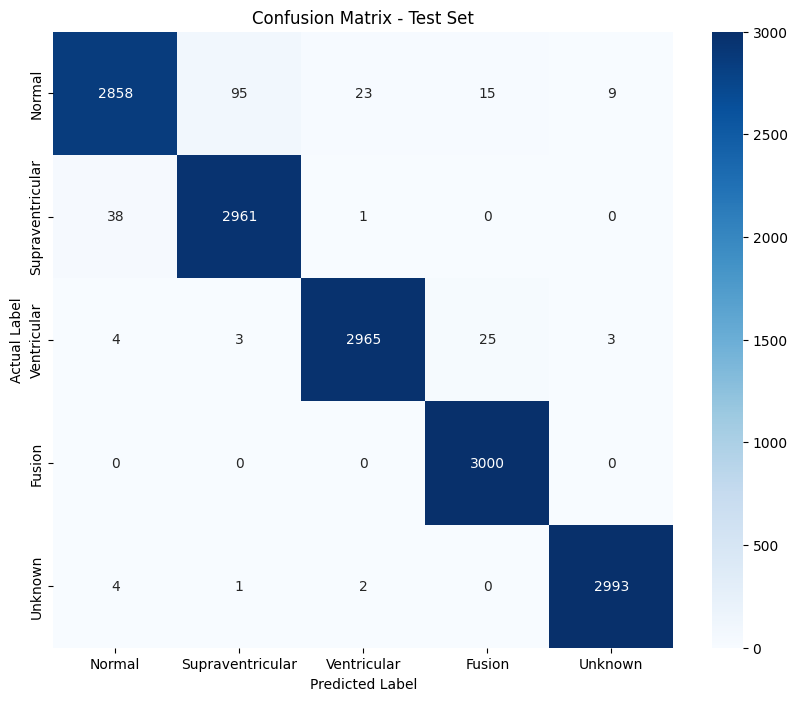

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

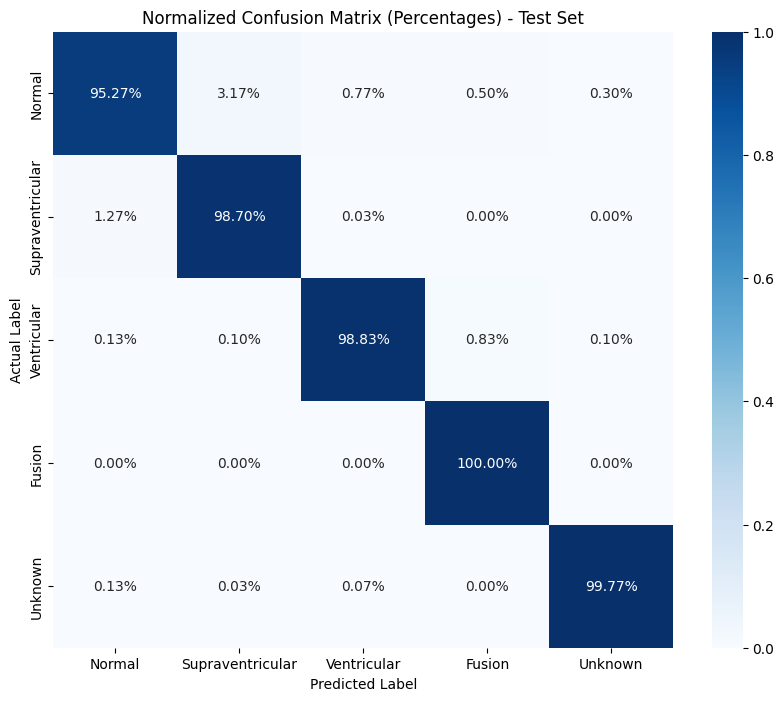

In [ ]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (3)


In [13]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate3 = 0.001
epochs = 20
batch_size = 32

tcn_model.compile(
    optimizer=Adam(learning_rate=learning_rate3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = tcn_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5830 - loss: 1.0129
Epoch 1: val_accuracy improved from None to 0.83620, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 92s 41ms/step - accuracy: 0.7059 - loss: 0.7570 - val_accuracy: 0.8362 - val_loss: 0.4417
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8308 - loss: 0.4579
Epoch 2: val_accuracy improved from 0.83620 to 0.86233, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 93s 42ms/step - accuracy: 0.8450 - loss: 0.4210 - val_accuracy: 0.8623 - val_loss: 0.3766
Epoch 3/20
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8714 - loss: 0.3507
Epoch 3: val_accuracy improved from 0.86233 to 0.91087, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 90s 41ms/step - accuracy: 0.8804 - loss:

# Evaluasi Metrik (3)


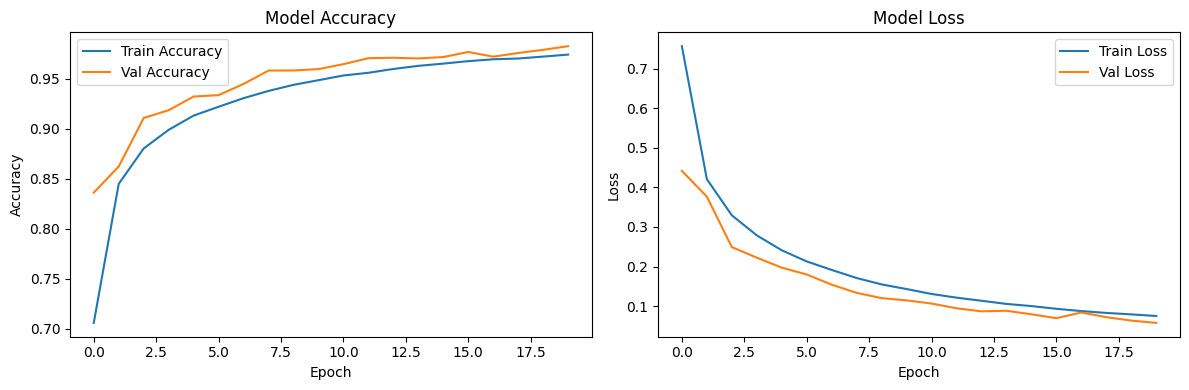

In [14]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = tcn_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time3 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss3, accuracy3 = tcn_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate3}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss3:.4f}")
print(f"Test Accuracy: {accuracy3:.4f}")
print(f"Total Prediction Time: {total_time3:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step
Learning Rate: 0.001
Epochs: 20
Batch size: 32
Test Loss: 0.0551
Test Accuracy: 0.9827
Total Prediction Time: 5.81 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.958     0.969     0.963      3000
Supraventricular      0.982     0.967     0.974      3000
     Ventricular      0.991     0.988     0.989      3000
          Fusion      0.987     0.992     0.990      3000
         Unknown      0.996     0.998     0.997      3000

        accuracy                          0.983     15000
       macro avg      0.983     0.983     0.983     15000
    weighted avg      0.983     0.983     0.983     15000



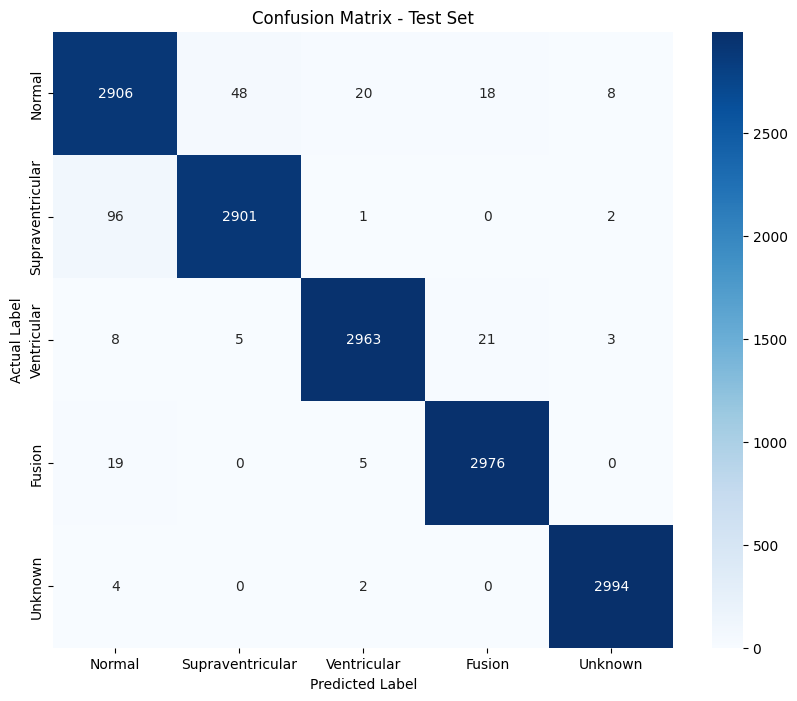

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

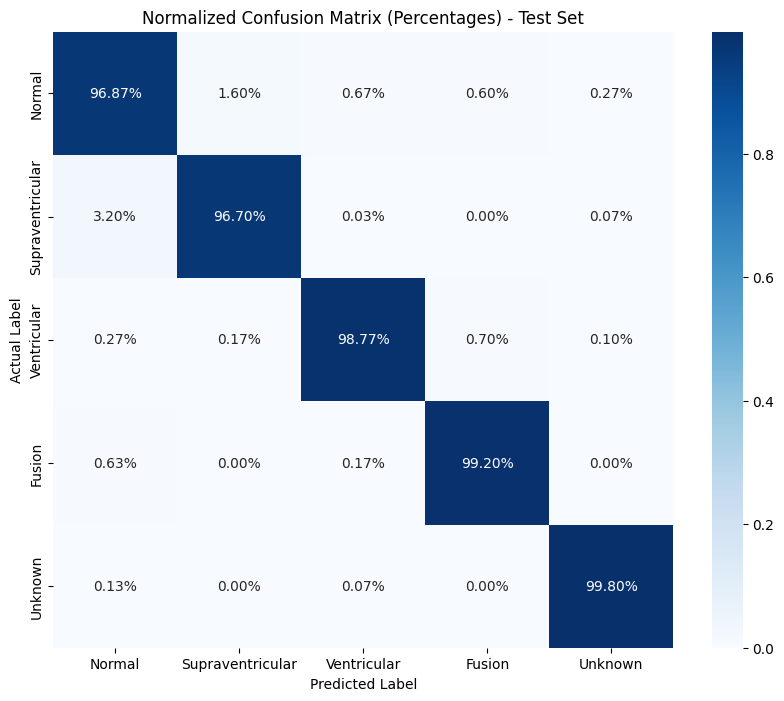

In [17]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (4)

In [18]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate4 = 0.0005
epochs = 20
batch_size = 32

tcn_model.compile(
    optimizer=Adam(learning_rate=learning_rate4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = tcn_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9795 - loss: 0.0603
Epoch 1: val_accuracy improved from None to 0.98547, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 90s 41ms/step - accuracy: 0.9800 - loss: 0.0587 - val_accuracy: 0.9855 - val_loss: 0.0481
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9817 - loss: 0.0529
Epoch 2: val_accuracy did not improve from 0.98547
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 89s 41ms/step - accuracy: 0.9810 - loss: 0.0543 - val_accuracy: 0.9850 - val_loss: 0.0491
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9827 - loss: 0.0510
Epoch 3: val_accuracy improved from 0.98547 to 0.98633, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 89s 41ms/step - accuracy: 0.9826 - loss: 0.0509 - val_accuracy: 0.9863 - val_loss: 0.0460
Epoch 4/20
2186/2188 ━━━━━━━━━━━━━━━━━━━

# Evaluasi Metrik (4)

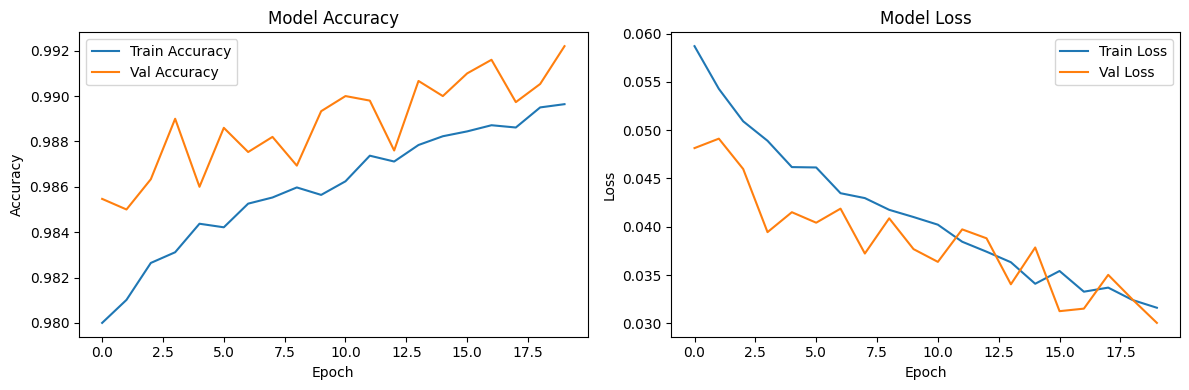

In [19]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = tcn_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time4 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss4, accuracy4 = tcn_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate4}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss4:.4f}")
print(f"Test Accuracy: {accuracy4:.4f}")
print(f"Total Prediction Time: {total_time4:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step
Learning Rate: 0.0005
Epochs: 20
Batch size: 32
Test Loss: 0.0313
Test Accuracy: 0.9913
Total Prediction Time: 5.94 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.990     0.976     0.983      3000
Supraventricular      0.986     0.993     0.990      3000
     Ventricular      0.993     0.991     0.992      3000
          Fusion      0.989     0.998     0.994      3000
         Unknown      0.998     0.999     0.999      3000

        accuracy                          0.991     15000
       macro avg      0.991     0.991     0.991     15000
    weighted avg      0.991     0.991     0.991     15000



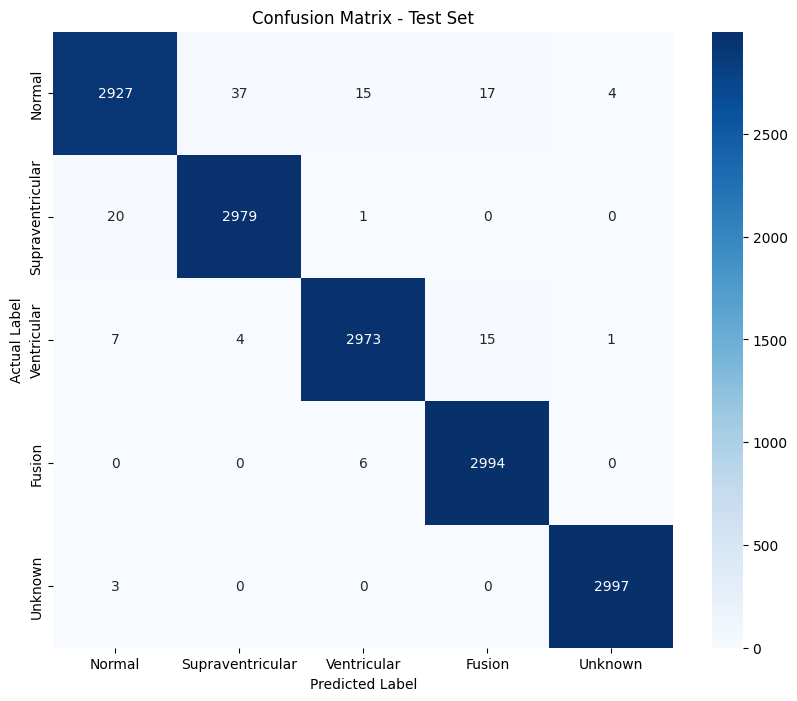

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

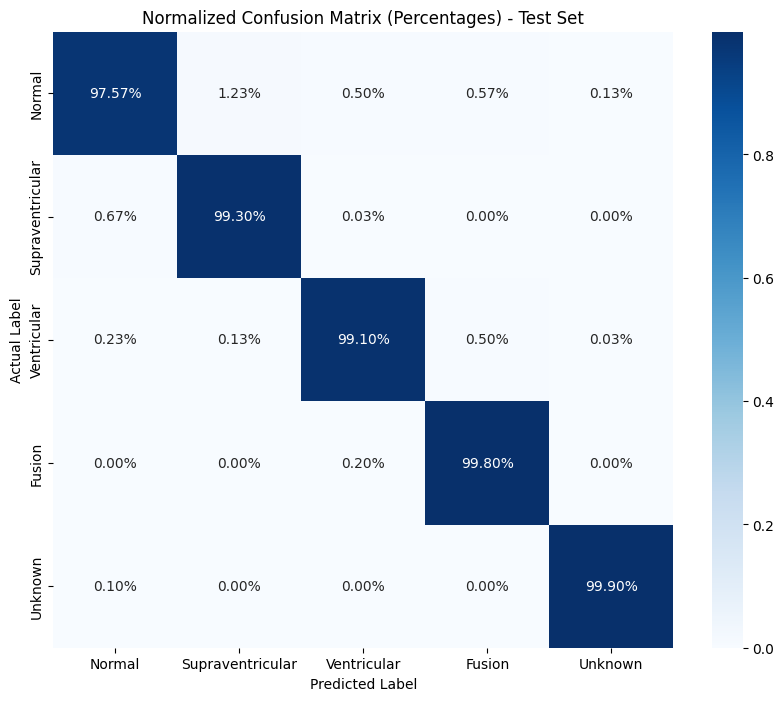

In [22]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Membuat data untuk tabel ringkasan
data = {
  'Learning Rate': [learning_rate1, learning_rate2, learning_rate3, learning_rate4],
  'Epochs': [epochs, epochs, epochs, epochs],
  'Batch Size': [batch_size, batch_size, batch_size, batch_size],
  'Test Loss': [f"{loss1:.4f}", f"{loss2:.4f}", f"{loss3:.4f}", f"{loss4:.4f}"],
  'Test Accuracy': [f"{accuracy1*100:.2f}%", f"{accuracy2*100:.2f}%", f"{accuracy3*100:.2f}%", f"{accuracy4*100:.2f}%"],
  'Eval Runtime (Detik)': [total_time1, total_time2, total_time3, total_time4]
}

# Membuat DataFrame
df_summary = pd.DataFrame(data)

# Menampilkan tabel
print("Summary Statistik Performa Model:")
display(df_summary)

# Penyimpanan dan Deployment

In [24]:
# 1. Simpan Model Utama
tcn_model.save('mitbih_cnn_model.keras')
print("Model berhasil disimpan sebagai 'mitbih_cnn_model.keras'")

# 2. Simpan OneHotEncoder (Sangat penting untuk tahap inferensi nanti)
with open('encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)
print("Encoder berhasil disimpan sebagai 'encoder.pkl'")

Model berhasil disimpan sebagai 'mitbih_cnn_model.keras'
Encoder berhasil disimpan sebagai 'encoder.pkl'
